In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import lstsq
from scipy import stats
import seaborn as sns

from scipy import interpolate


from utils import *


In [35]:
df = process_roi_txt_to_excel("230816_M06_Au06_Primary.txt", "230816_M06_Au06_Primary.xlsx")

In [36]:
xi=list(df.columns)
t=df.index.to_numpy()

data_cor=df[xi].to_numpy(dtype=float)

data_unc=df[xi].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))

steps=len(data_cor)

d_xi=[]

for i in range(1,len(xi)):
     d_xi.append(float(xi[i])-float(xi[i-1]))

In [37]:
pd.DataFrame(data_unc)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,933.850606,663.624157,442.346666,257.309362,134.269179,68.843769,27.126944,19.972423,8.817148,7.311976,5.293689,3.187518,2.546715,2.232711,1.516688,0.571357,1.455536,2.331346
1,1518.988616,1124.406237,932.652734,710.037692,565.924934,318.331032,186.740461,119.834476,69.407023,54.857011,33.085107,31.656062,17.770175,10.265863,2.940128,5.095382,2.995698,1.384879
2,1610.942195,696.990353,546.839969,464.950297,446.648356,298.704071,228.333079,177.452783,139.553569,131.923939,109.235612,103.085085,60.283455,31.585087,21.839531,17.535409,6.890073,1.971293
3,6818.803892,2022.724617,1366.771273,793.235245,454.013235,244.797418,175.498941,142.460108,118.345088,127.246404,124.466013,113.262921,82.226019,58.514325,47.486608,24.265523,26.036459,12.931838
4,17039.696848,6155.882475,4994.904271,3400.241291,1742.764029,995.222696,438.674007,217.386012,144.673888,129.942879,97.115850,117.515652,75.682748,63.729809,44.070615,34.335554,36.763103,19.698592
5,24680.945195,10381.546282,9739.355739,7995.501121,5245.213975,3585.179352,1889.687982,1114.280238,722.922836,422.209014,168.455389,120.829357,69.519470,54.895086,32.274127,24.118042,31.924308,21.551183
6,25910.849597,12006.994042,12404.359069,11421.219855,8820.828844,7319.911849,4558.448145,3118.985399,2417.398143,1558.714750,740.714545,381.655757,154.095698,61.933935,42.160213,28.329080,24.065538,3.709576
7,22303.492916,11253.563826,12144.856850,12025.678379,10264.909444,9741.785184,6692.600104,5135.797991,4591.794253,3569.010096,2146.141679,1298.667098,638.465347,229.304480,72.964816,23.374187,24.401365,17.633790
8,17053.161558,8958.164605,10297.051617,10357.230777,9383.719634,10222.644318,7236.690853,6124.549904,6025.563287,5276.029331,3733.625303,2834.303926,1719.803140,820.749766,287.078380,80.162647,32.874996,33.630712
9,12518.121010,6785.235967,7702.946015,8138.330430,7745.147456,9494.088914,6632.093154,5862.654030,6145.768625,5886.504819,4596.281258,4192.883727,3033.601982,1881.761772,857.170240,308.530795,80.391098,14.256496


In [61]:
pd.DataFrame(data_unc/np.max(data_unc))[[11,12,13,14,15]]

,11,12,13,14,15
0,0.000123,0.000098,0.000086,0.000059,0.000022
1,0.001222,0.000686,0.000396,0.000113,0.000197
2,0.003978,0.002327,0.001219,0.000843,0.000677
3,0.004371,0.003173,0.002258,0.001833,0.000937
4,0.004535,0.002921,0.002460,0.001701,0.001325
5,0.004663,0.002683,0.002119,0.001246,0.000931
6,0.014730,0.005947,0.002390,0.001627,0.001093
7,0.050121,0.024641,0.008850,0.002816,0.000902
8,0.109387,0.066374,0.031676,0.011079,0.003094
9,0.161820,0.117078,0.072624,0.033082,0.011907


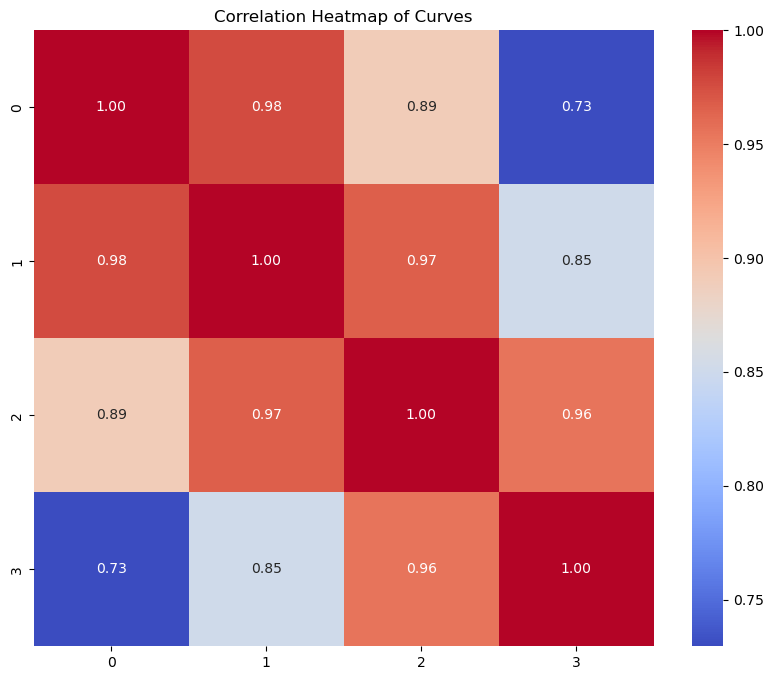

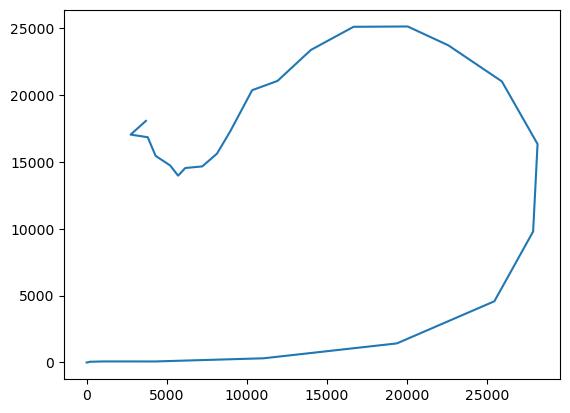

In [62]:
plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(np.array([entry/np.max(entry) for entry in data_unc[:,11:15].T]).T).corr(method="pearson"), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Curves")
plt.show()

plt.plot(data_cor[:,11],data_cor[:,15])

In [63]:
def plot_all_columns(data_array):
    """
    Function to plot all columns in a 2D array. Each column is stored 
    in a dynamically created variable named roi1, roi2, ..., roiN.

    Parameters:
    data_array (ndarray): 2D array where each column is a separate dataset to plot.
    """
    # Dictionary to hold dynamically created variables
    roi_dict = {}
    
    # Extract the first column and compute its maximum
    roi1_max = np.max(data_array[:, 0])
    
    # Loop through columns in the data array
    for i in range(data_array.shape[1]):
        # Dynamically name the variable
        var_name = f'roi{i+1}'
        roi_dict[var_name] = data_array[:, i] / roi1_max  # Normalize by roi1 max
        
        # Plot the normalized column
        plt.plot(roi_dict[var_name], label=var_name)
    
    # Add legend and labels
    plt.legend()
    plt.xlabel('Index')
    plt.ylabel('Normalized Value')
    plt.title('Normalized Plots of All Columns')
    plt.show()
    
    return roi_dict  # Return dictionary of normalized variables

In [64]:
data_unc[:,11:15].shape

(30, 4)

In [65]:
[entry/np.max(entry) for entry in data_unc[:,11:15].T]

[array([6.85697361e-04, 6.80983700e-03, 2.21756147e-02, 2.43650658e-02,
        2.52799114e-02, 2.59927540e-02, 8.21016054e-02, 2.79368650e-01,
        6.09714117e-01, 9.01971160e-01, 1.00000000e+00, 9.23756345e-01,
        7.86989421e-01, 6.11333147e-01, 4.49198275e-01, 3.36398665e-01,
        2.35928370e-01, 1.67249379e-01, 1.20083107e-01, 8.78210680e-02,
        6.43124274e-02, 4.92314080e-02, 3.68419879e-02, 2.65268055e-02,
        2.07354558e-02, 1.59739290e-02, 1.11316712e-02, 8.31787164e-03,
        5.05264908e-03, 5.74304907e-03]),
 array([6.33194382e-04, 4.41823092e-03, 1.49883849e-02, 2.04440045e-02,
        1.88171392e-02, 1.72847521e-02, 3.83130935e-02, 1.58742800e-01,
        4.27597782e-01, 7.54249977e-01, 9.71967865e-01, 1.00000000e+00,
        9.02463360e-01, 7.53963729e-01, 5.71064097e-01, 4.23622469e-01,
        3.03870232e-01, 2.25990574e-01, 1.69291352e-01, 1.24752466e-01,
        8.66123076e-02, 6.36569038e-02, 4.81652480e-02, 3.91701111e-02,
        3.13841830e-02

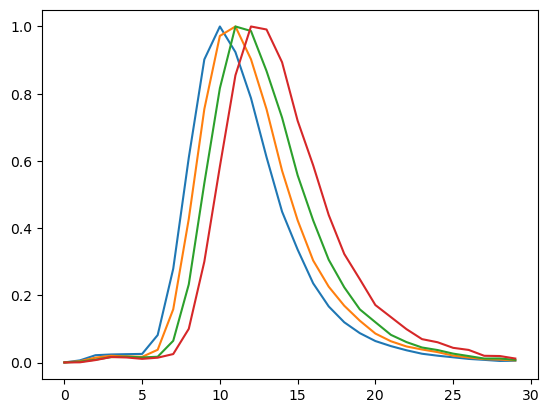

In [66]:
plt.plot(np.array([entry/np.max(entry) for entry in data_unc[:,11:15].T]).T)

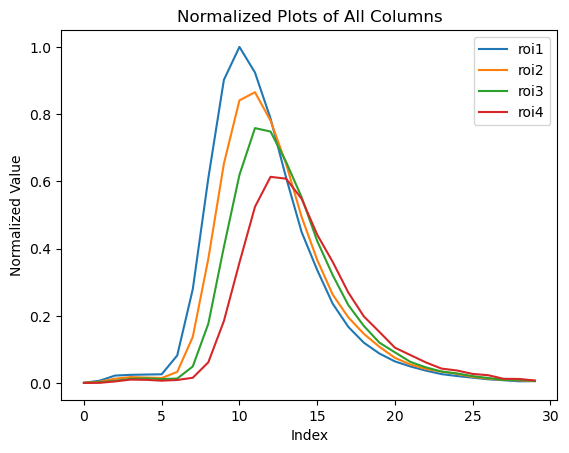

In [67]:
rois = plot_all_columns(data_unc[:,11:15])

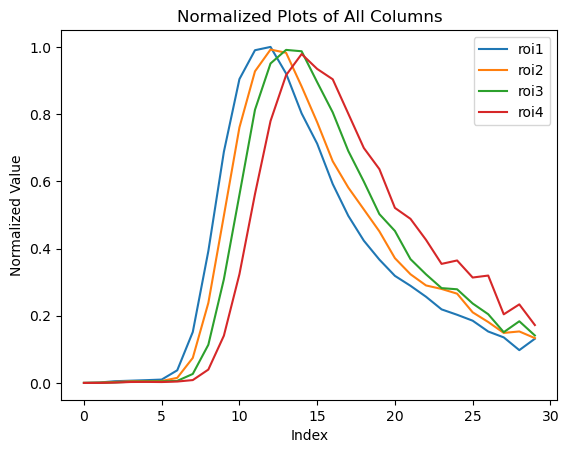

In [68]:
rois = plot_all_columns(data_cor[:,11:15])

In [69]:
xi=xi[11:15]

In [70]:
rois

{'roi1': array([1.13157068e-04, 1.33216929e-03, 5.14247109e-03, 6.69787861e-03,
        8.23794184e-03, 1.00408149e-02, 3.75960144e-02, 1.51649617e-01,
        3.92340725e-01, 6.88023517e-01, 9.04240850e-01, 9.90182049e-01,
        1.00000000e+00, 9.20836534e-01, 8.02077195e-01, 7.12042380e-01,
        5.91977552e-01, 4.97465626e-01, 4.23403039e-01, 3.67066085e-01,
        3.18650011e-01, 2.89157715e-01, 2.56512820e-01, 2.18939672e-01,
        2.02874092e-01, 1.85267074e-01, 1.53045426e-01, 1.35564411e-01,
        9.76171454e-02, 1.31529445e-01]),
 'roi2': array([9.04085258e-05, 7.47815110e-04, 3.00728201e-03, 4.86249063e-03,
        5.30542157e-03, 5.77700772e-03, 1.51796061e-02, 7.45556930e-02,
        2.38065087e-01, 4.97793318e-01, 7.60429848e-01, 9.27429145e-01,
        9.92164788e-01, 9.82603205e-01, 8.82238632e-01, 7.75806997e-01,
        6.59684613e-01, 5.81583416e-01, 5.16451986e-01, 4.51146725e-01,
        3.71297283e-01, 3.23490227e-01, 2.90150248e-01, 2.79716084e-01,
      

In [71]:
roi1 = rois['roi1']
roi2 = rois['roi2']
roi3 = rois['roi3']
roi4 = rois['roi4']



In [72]:
def find_roots(x, y):
    s = np.abs(np.diff(np.sign(y))).astype(bool)
    return x[:-1][s] + np.diff(x)[s] / (np.abs(y[1:][s] / y[:-1][s]) + 1)

In [73]:
plt.rcParams['axes.prop_cycle'].by_key()['color']

['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22',
 '#17becf']

In [74]:
def process_and_plot_rois(rois, t):
    """
    Processes and plots multiple ROIs from a dictionary using cubic spline interpolation and calculates max ratios.

    Parameters:
    - rois (dict): Dictionary where keys are ROI names (e.g., 'roi1', 'roi2') and values are 1D arrays of data.
    - t (array): Time array corresponding to the ROIs.

    Returns:
    - results (dict): Dictionary where keys are ROI names and values are a dictionary with:
        - 'cubic_spline': The cubic spline object for the ROI.
        - 'max_value': Maximum value of the interpolated data.
        - 'half_max': Half-maximum value of the interpolated data.
        - 'roots': Roots of the cubic spline.
        - 'ratios': List of ratios between consecutive max values (calculated for all ROIs together).
    """
    results = {}
    maxima = []
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    plt.figure()
    plt.style.use('default')
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    for i, (roi_name, roi_data) in enumerate(rois.items()):
        # Interpolate using Cubic Spline
        cu = interpolate.CubicSpline(t.ravel(), roi_data.ravel())
        x_interp = np.linspace(0, max(t), 500)
        y_interp = cu(x_interp)

        # Compute max and half-max
        max_value = np.max(y_interp)
        half_max = max_value / 2
        maxima.append(max_value)

        # Plot interpolated curve
        color = colors[i % len(colors)]
        plt.plot(x_interp, y_interp, 'k', linewidth=1.2, label="Spline")

        # Highlight max and half-max
        plt.hlines(max_value, -9, max(t)+10, linestyle=(0, (1, 1)), color=color, label="Maximum")
        plt.hlines(half_max, -9, max(t)+10, linestyle='--', color=color, label="Half-Maximum")

        # Plot the original points
        plt.plot(t, roi_data, marker='.', markersize=8, linestyle='none', color=color, label="Experimental Data")

        # Save results
        results[roi_name] = {
            'cubic_spline': cu,
            'max_value': max_value,
            'half_max': half_max,
            'roots': cu.roots()
        }
    
    # Compute ratios of maxima
    ratios = [maxima[i] / maxima[i + 1] for i in range(len(maxima) - 1)]

    # Add ratios to results
    results['ratios'] = ratios

    plt.xlabel("Time [min]", fontsize=16)
    plt.ylabel("Activity [a.u.]", fontsize=16)
    
    # Remove duplicate labels while keeping the first occurrence
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_labels = {}
    unique_handles = []

    for handle, label in zip(handles, labels):
        if label not in unique_labels:  # Keep first occurrence
            unique_labels[label] = handle
            unique_handles.append(handle)

    # Add legend with unique labels
    plt.legend(unique_handles, unique_labels.keys(), fontsize=10)
    
    plt.savefig("local_velocity_change_hmax.pdf", format="pdf")  
    
    plt.show()
    
   
    
    return results

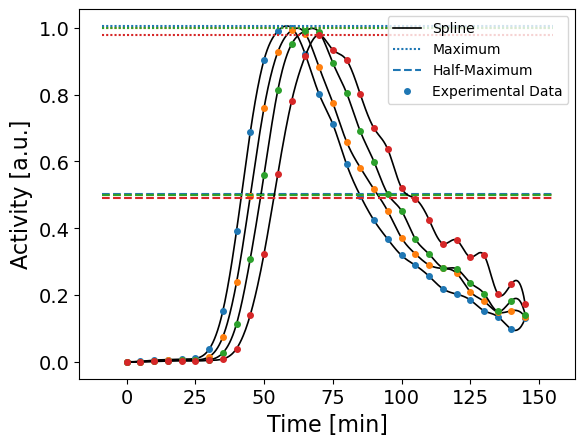

In [75]:
results=process_and_plot_rois(rois,t)

In [76]:
results['ratios']

[np.float64(1.0067598919413772),
 np.float64(1.0005966594870226),
 np.float64(1.020018826498199)]

In [77]:
def compute_hmax_times(results, time_range):
    """
    Computes the half-max times for each ROI in the results using the find_roots function.

    Parameters:
    - results (dict): Dictionary containing ROI results with cubic splines and half-max values.
    - time_range (array): Array of time values to use for interpolation (e.g., np.linspace).

    Returns:
    - hmax_times (dict): Dictionary with ROI names as keys and the first half-max time as values.
    """
    def find_roots(x, y):
        """
        Finds the roots of a signal crossing zero using interpolation.
        """
        s = np.abs(np.diff(np.sign(y))).astype(bool)
        return x[:-1][s] + np.diff(x)[s] / (np.abs(y[1:][s] / y[:-1][s]) + 1)

    hmax_times = {}

    for roi_name, data in results.items():
        if roi_name == "ratios":  # Skip the "ratios" key if present
            continue
        
        # Extract the cubic spline and half-max value
        cubic_spline = data['cubic_spline']
        half_max = data['half_max']
        
        # Evaluate the cubic spline minus the half-max value
        y_interp = cubic_spline(time_range) - half_max
        
        # Find roots
        roots = find_roots(time_range, y_interp)
        
        # Take the first root if any, otherwise assign NaN
        hmax_times[roi_name] = roots[0] if len(roots) > 0 else np.nan

    return hmax_times



In [78]:
hmaxi = np.array(list(compute_hmax_times(results,np.linspace(0,145,500)).values()))

In [79]:
hmaxi

array([41.85596063, 45.03047608, 48.85422759, 53.5123754 ])

In [80]:
points=np.array(xi[:], dtype="float")

In [81]:
points

array([], dtype=float64)

[3.11101999 1.58215304] 0.19199717218402065


np.float64(0.9924400600900326)

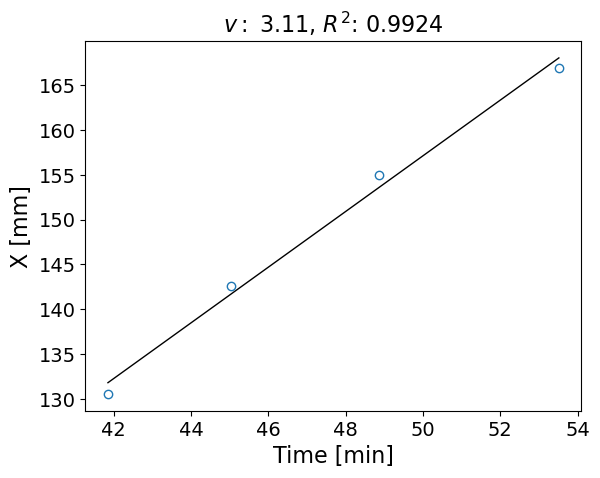

In [59]:
points=np.array(xi, dtype="float")

Iv=np.ones((len(hmaxi),1))
Mv=np.array(np.append(Iv,hmaxi.reshape(len(hmaxi),1),axis=1))


mbinter_v=np.array([]).reshape(0,3)
b1v, m1v = lstsq(Mv, points)[0]
mbinter_v = np.vstack((mbinter_v, (m1v, b1v, -b1v/m1v)))


plt.style.use('default')
    
plt.xticks(fontsize=14)
plt.yticks(fontsize=14) 


for i in range (0,len(mbinter_v)):
    plt.plot(hmaxi, mbinter_v[i][0]*np.array(hmaxi)+mbinter_v[i][1], label=np.round(mbinter_v[i][0],3),color='k', linewidth=1)    
    

    
#np.polyfit(intercepts,points,1)
plt.plot(hmaxi, points, marker='o', linestyle='None',markerfacecolor='none')


plt.xlabel("Time [min]",fontsize=16)
plt.ylabel("X [mm]",fontsize=16)
plt.title(f"$v:$ {np.around(mbinter_v[0][0],2)}, $R^2$: {np.around(np.corrcoef(hmaxi, points)[0,1]**2, 4)}", fontsize=16)
np.corrcoef(hmaxi, points)[0,1]**2


plt.savefig("local_velocity_change_hmaxfit.pdf", format="pdf")  
fit, V=np.polyfit(hmaxi,points,1, cov=True)
print(fit,np.sqrt(V[0][0]))

np.corrcoef(hmaxi, points)[0,1]**2


In [60]:
0.191 / 3.111 * 100

6.139504982320797